# NYC Permit Approval Forecasting · Notebook 1: Data cleaning and exploration
**Author:** Atul Iwale · **Project 15** of the AEC Fieldwork portfolio · **Real, public data**

**Business question:** a developer or contractor files a major job with the New York City Department of Buildings (DOB). How long until the plans are approved, so the programme, financing and holding costs can be planned on facts?

**Data source:** NYC Open Data, [DOB NOW: Build – Job Application Filings](https://data.cityofnewyork.us/Housing-Development/DOB-NOW-Build-Job-Application-Filings/w9ak-ipjd), downloaded 24 Sep 2026 with `src/download.py`. The extract covers the four major job types (New Building, Alteration CO, ALT-CO, Full Demolition) and 55 columns. Applicant and owner names, house numbers and streets were never downloaded.

**Licence:** NYC's Open Data Law requires public datasets to be available "without registration requirement, license requirement, or usage restrictions". The City asks re-publishers to identify the source, version and changes made (this notebook and the README do that), and gives no warranty of accuracy.

**Contents**
1. Load the raw extract · 2. One row per job: initial filings and duplicates · 3. Data quality checks · 4. The outcome: time to approval, and filings still open
5. Why open filings matter: the censoring bias · 6. Approval times by job type, borough and year · 7. DOB workload · 8. Declared cost check · 9. Save

In [1]:
import sys, json, warnings; warnings.filterwarnings('ignore')
sys.path.insert(0, '../src')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sksurv.nonparametric import kaplan_meier_estimator
import cleaning as C
pd.set_option('display.width', 170); pd.set_option('display.max_colwidth', 120)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})

## 1. Load the raw extract
The raw file (80 MB) is not stored in the repository; `src/download.py` rebuilds it from the NYC Open Data API. Everything is read as text first.

In [2]:
raw = C.load_raw('../data/raw/dob_major_jobs.csv')
print(f'{len(raw):,} filing records, {raw.shape[1]} columns')
raw.job_type.value_counts().to_frame('filing records')

131,515 filing records, 55 columns


,filing records
job_type,
New Building,56584
Alteration CO,50807
ALT-CO - New Building with Existing Elements to Remain,16356
Full Demolition,7768


## 2. One row per job: initial filings and duplicates
A DOB job number such as `B00123456` has an **initial filing** (`-I1`) and often many later filings: subsequent filings (`-S1`, `-S2`), post-approval amendments (`-P1` ...) and others. Approval time is about the initial filing, so each job is represented by its `-I1` row.

In [3]:
s = C.split_filing_number(raw)
print('Filing number suffixes (first letter):', s.filing_suffix.str[0].value_counts().to_dict())
print(f'Duplicate filing numbers: {raw.job_filing_number.duplicated().sum()}')
dup = raw[raw.job_filing_number.duplicated(keep=False)].sort_values('job_filing_number')
dup[['job_filing_number', 'filing_status', 'current_status_date', 'approved_date']].head(6)

Filing number suffixes (first letter): {'S': 49948, 'P': 42369, 'I': 32060, 'A': 4542, 'Z': 1661, 'B': 748, 'C': 122, 'Y': 50, 'D': 14, 'F': 1}
Duplicate filing numbers: 128


,job_filing_number,filing_status,current_status_date,approved_date
2269,B00539478-B2,Filing Withdrawn,2026-03-09T13:36:13.000,2026-03-09T08:56:58.000
2270,B00539478-B2,Approved,2026-03-09T13:36:13.000,2026-03-09T08:56:58.000
2271,B00539478-B3,Filing Withdrawn,2026-01-27T14:31:36.000,2026-01-27T08:53:54.000
2272,B00539478-B3,Approved,2026-01-27T14:31:36.000,2026-01-27T08:53:54.000
3028,B00561184-A3,Approved,2026-02-17T15:48:38.000,2026-02-17T10:48:38.000
3029,B00561184-A3,Approved,2026-02-17T15:48:38.000,2026-02-17T10:48:38.000


In [4]:
dedup = C.dedupe(s)
initial = C.tidy(dedup[dedup.is_initial])
print(f'{dedup.job_number.nunique():,} distinct jobs; {len(initial):,} initial filings after removing duplicates')
print(f'Initial filings with no filing date: {initial.filing_date.isna().sum()} (dropped)')

32,086 distinct jobs; 32,060 initial filings after removing duplicates
Initial filings with no filing date: 180 (dropped)


Duplicates are the same filing captured twice with different status dates; I keep the latest state. The 180 initial filings with no filing date can't be timed, so they are dropped.

## 3. Data quality checks

In [5]:
df = initial[initial.filing_date.notna()].copy()
checks = {
    'filing date range': f'{df.filing_date.min():%d %b %Y} to {df.filing_date.max():%d %b %Y}',
    'review type': df.filing_review_type.value_counts().to_dict(),
    'declared cost = 0': f'{(df.initial_cost.fillna(0) <= 0).mean():.1%}',
    'floor area = 0 or missing': f'{(df.total_construction_floor_area.fillna(0) <= 0).mean():.1%}',
    'job description empty': f'{(df.job_description == "").mean():.1%}',
    'status "Filing Withdrawn"': int(df.filing_status.eq('Filing Withdrawn').sum()),
}
pd.Series(checks, dtype=object).to_frame('value')

,value
filing date range,01 Mar 2021 to 22 Sep 2026
review type,"{'Standard Plan Examination': 29123, 'Professional Certification': 2757}"
declared cost = 0,20.6%
floor area = 0 or missing,0.0%
job description empty,2.6%
"status ""Filing Withdrawn""",1186


Two review routes exist. **Standard Plan Examination** means a DOB examiner reviews the plans; it covers 91% of these major jobs and is where the waiting happens. **Professional Certification** means the architect or engineer self-certifies, and those filings are approved faster. The forecasting model is for standard plan examination.

In [6]:
df = C.add_outcome(df)
print('Median days to approval, approved filings only:'); print(df[df.event == 1].groupby('filing_review_type').duration.median().to_dict())
print(f"\nApproved before filed (impossible dates): {df.bad_dates.sum()} filings, excluded from modelling")

Median days to approval, approved filings only:
{'Professional Certification': 42.0, 'Standard Plan Examination': 106.0}

Approved before filed (impossible dates): 21 filings, excluded from modelling


## 4. The outcome: time to approval, and filings still open
For each initial filing:
- **Approved** (`event = 1`): duration = days from filing to DOB approval.
- **Still open** (`event = 0`): all we know is that it has waited *at least* this long. Its duration runs to the data date (23 Sep 2026). A withdrawn filing is closed at its withdrawal date.

This is called **censoring**, and it is the defining feature of this data.

In [7]:
df = C.add_split(C.add_features(df, df))
pe = df[df.filing_review_type.eq('Standard Plan Examination') & (df.bad_dates == 0)]
tab = pe.groupby(pe.filing_date.dt.year).agg(filings=('event', 'size'), approved=('event', 'mean'), withdrawn=('withdrawn', 'mean'))
tab['still open'] = 1 - tab.approved - tab.withdrawn
tab.round(3)

,filings,approved,withdrawn,still open
filing_date,,,,
2021,3144,0.867,0.026,0.107
2022,4467,0.857,0.030,0.113
2023,5077,0.827,0.039,0.134
2024,5158,0.835,0.040,0.125
2025,6476,0.747,0.030,0.224
2026,4780,0.356,0.007,0.637


Only 36% of 2026 filings are approved yet, simply because they are young. Even among 2021 filings, 13% are still open or withdrawn years later: jobs stuck in objections.

## 5. Why open filings matter: the censoring bias
The obvious shortcut, "take the approved filings and average their times", throws away the slow jobs that aren't approved yet. The **Kaplan–Meier estimator** uses every filing: an open filing counts as "not approved yet" for as long as it has been open.

In [8]:
def km_median(g):
    t, s = kaplan_meier_estimator(g.event.astype(bool), g.duration.clip(lower=0))
    return float(t[np.argmax(s <= .5)]) if (s <= .5).any() else np.nan
bias = pd.DataFrame({'filings': pe.groupby(pe.filing_date.dt.year).size(),
                     'naive median (approved only)': pe[pe.event == 1].groupby(pe.filing_date.dt.year).duration.median(),
                     'Kaplan-Meier median (all filings)': pe.groupby(pe.filing_date.dt.year).apply(km_median)})
bias.loc['All years'] = [len(pe), pe[pe.event == 1].duration.median(), km_median(pe)]
bias

,filings,naive median (approved only),Kaplan-Meier median (all filings)
filing_date,,,
2021,3144.0,133.0,161.0
2022,4467.0,144.5,181.0
2023,5077.0,92.0,123.0
2024,5158.0,97.0,123.0
2025,6476.0,113.0,161.0
2026,4780.0,74.0,182.0
All years,29102.0,107.0,154.0


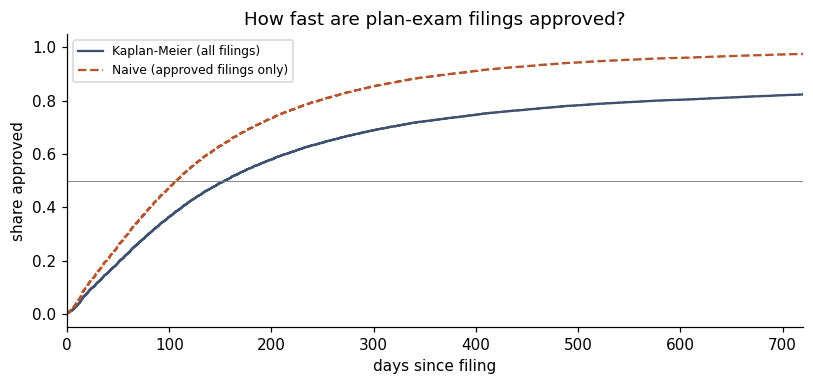

In [9]:
fig, ax = plt.subplots(figsize=(7.5, 3.6))
t, s = kaplan_meier_estimator(pe.event.astype(bool), pe.duration.clip(lower=0))
ax.step(t, 1 - s, where='post', color='#3F5170', label='Kaplan-Meier (all filings)')
ap = np.sort(pe[pe.event == 1].duration.values); ax.step(ap, np.arange(1, len(ap) + 1) / len(ap), where='post', color='#B4552E', ls='--', label='Naive (approved filings only)')
ax.set_xlim(0, 720); ax.set_xlabel('days since filing'); ax.set_ylabel('share approved'); ax.axhline(.5, color='grey', lw=.6)
ax.legend(fontsize=8); ax.set_title('How fast are plan-exam filings approved?'); plt.tight_layout(); plt.show()

The naive median is **107 days**; the Kaplan–Meier median is **154 days**. Ignoring open filings makes DOB look about a third faster than it is, and the gap is largest for recent years, where most slow jobs are still open (2026: 74 days naive, 182 days real). A developer planning on the naive number would start the programme about seven weeks too early. Notebook 2 uses survival models, which handle open filings properly.

## 6. Approval times by job type, borough and year

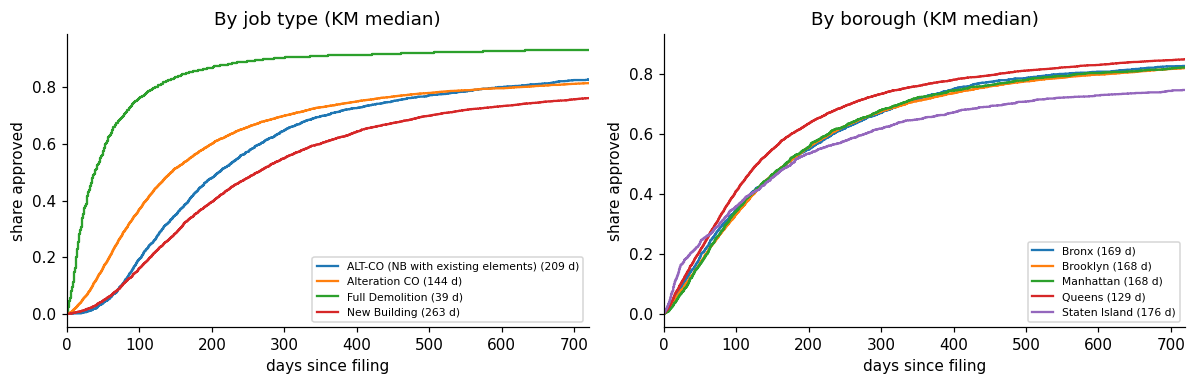

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
for j, g in pe.groupby('job_type'):
    t, s = kaplan_meier_estimator(g.event.astype(bool), g.duration.clip(lower=0)); ax[0].step(t, 1 - s, where='post', label=f'{j} ({km_median(g):.0f} d)')
for b, g in pe.groupby('borough'):
    t, s = kaplan_meier_estimator(g.event.astype(bool), g.duration.clip(lower=0)); ax[1].step(t, 1 - s, where='post', label=f'{b} ({km_median(g):.0f} d)')
for a, title in zip(ax, ['By job type (KM median)', 'By borough (KM median)']):
    a.set_xlim(0, 720); a.set_xlabel('days since filing'); a.set_ylabel('share approved'); a.legend(fontsize=7); a.set_title(title)
plt.tight_layout(); plt.show()

In [11]:
g = pe.groupby('job_type').agg(filings=('event', 'size'), approved_so_far=('event', 'mean'))
g['KM median days'] = pe.groupby('job_type').apply(km_median)
x = pe[(pe.event == 1) & pe.first_permit_date.notna()]
print(f'After approval, the first permit follows a median {(x.first_permit_date - x.approved_date).dt.days.median():.0f} days later.')
g.round(2)

After approval, the first permit follows a median 56 days later.


,filings,approved_so_far,KM median days
job_type,,,
ALT-CO (NB with existing elements),2693,0.72,209.0
Alteration CO,13156,0.74,144.0
Full Demolition,5209,0.86,39.0
New Building,8044,0.69,263.0


New Buildings take the longest (median about 260 days to approval), full demolitions the least (about 40 days). Queens is noticeably faster than the other boroughs. And approval is not the finish line: the first permit follows a median of about two months later.

## 7. DOB workload
For each filing I measure the workload on the day it was filed, using only what was known that day (`workload()` in `src/cleaning.py`): plan-exam filings in the same borough in the previous 30 days, and the **open queue**, filings from the previous 180 days not yet approved or withdrawn. The first six months of DOB NOW (March–August 2021) are a warm-up period with no history for the queue, so they are left out of modelling.

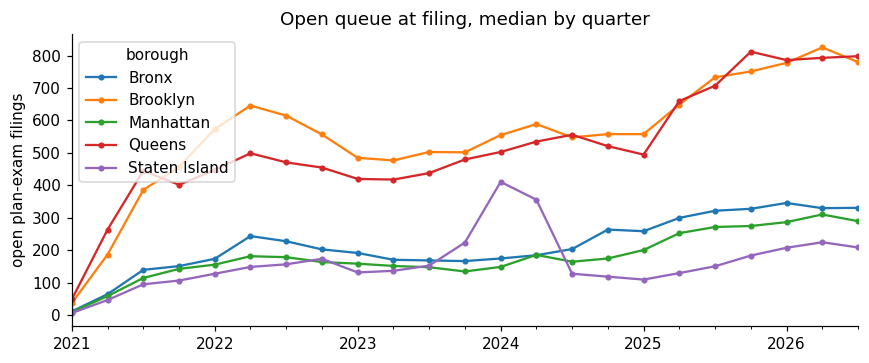

In [12]:
q = pe.groupby([pe.filing_date.dt.to_period('Q'), 'borough']).open_queue.median().unstack()
ax = q.plot(figsize=(8, 3.4), marker='.'); ax.set_ylabel('open plan-exam filings'); ax.set_xlabel(''); ax.set_title('Open queue at filing, median by quarter'); plt.tight_layout(); plt.show()

The open queue grew steadily from 2024 into 2026 in every borough. That matches the Kaplan–Meier medians rising again for 2025 filings. Notebook 2 tests whether workload helps predict an individual filing's wait. (It turns out to add little, because the queue rises steadily with time and its effect can't be separated from everything else that changed.)

## 8. Declared cost check
Filing fees for alterations are based on the declared job cost, so under-declaring saves fees. For New Buildings, 61% of filings declare \$0, because their fees are driven by floor area rather than cost, so the check is only meaningful for **Alteration CO** jobs.

In [13]:
print('Share of filings declaring $0, by job type:'); print(pe.groupby('job_type').cost_zero.mean().round(3).to_dict())
alt = pe[(pe.job_type == 'Alteration CO') & pe.cost_per_sqft.notna()]
pct = alt.cost_per_sqft.quantile([.01, .05, .25, .5, .75, .95]).round(1)
print('\nAlteration CO, declared cost per sq ft of work area, percentiles:'); print(pct.to_dict())
low = alt[alt.cost_per_sqft < 5]
print(f'\n{len(low)} of {len(alt):,} Alteration CO filings ({len(low)/len(alt):.1%}) declare under $5 per sq ft. Examples:')
low.nsmallest(4, 'cost_per_sqft')[['job_number', 'borough', 'initial_cost', 'total_construction_floor_area', 'job_description']]

Share of filings declaring $0, by job type:
{'ALT-CO (NB with existing elements)': 0.007, 'Alteration CO': 0.03, 'Full Demolition': 0.068, 'New Building': 0.611}



Alteration CO, declared cost per sq ft of work area, percentiles:
{0.01: 0.2, 0.05: 3.1, 0.25: 46.7, 0.5: 97.9, 0.75: 150.0, 0.95: 353.7}

793 of 12,759 Alteration CO filings (6.2%) declare under $5 per sq ft. Examples:


,job_number,borough,initial_cost,total_construction_floor_area,job_description
114734,X00635014,Bronx,1.0,27500.0,No work application filed for change of use only. Change use of 2nd floor from store to community facility. Change u...
26637,B01018106,Brooklyn,1.0,14600.0,APPLICATION FILED TO AMEND CERTIFICATE OF OCCUPANCY TO REFLECT CHANGE ON SCHEDULE OF OCCUPANCY
80828,Q00962690,Queens,1.0,12960.0,PAA TO INCLUDE EXISTING CELLAR FLOOR PLAN FOR REFERENCE ONLY (NO WORK PROPOSED)
63950,M08053981,Manhattan,1.0,11512.0,Application filed for zoning and egress review and to obtain a new Certificate of Occupancy. See comments for comple...


In [14]:
NO_WORK = r'no work|no change|reference only|amend(?:ed|ment)? (?:the )?(?:c of o|certificate|co\b)|change of use only|to obtain a new certificate|legalize existing|schedule of occupancy'
low = low.assign(no_work=low.job_description.str.lower().str.contains(NO_WORK, regex=True))
print(f"Low-cost filings whose description says there is no physical work (CO amendments, change of use only): {low.no_work.sum()} of {len(low)}")
review = low[~low.no_work]
print(f"Left for review: {len(review)} filings ({len(review)/len(alt):.1%} of Alteration CO filings)")
review.sample(4, random_state=1)[['job_number', 'borough', 'initial_cost', 'total_construction_floor_area', 'job_description']]

Low-cost filings whose description says there is no physical work (CO amendments, change of use only): 232 of 793
Left for review: 561 filings (4.4% of Alteration CO filings)


,job_number,borough,initial_cost,total_construction_floor_area,job_description
65127,Q00499386,Queens,2000.00,2901.00,JOB IS FILED TO OBTAIN C OF O FOR EXISTING 2 FAMILY BUILDING. MINOR INTERIOR WORK IS PROPOSED (to replace some light...
87755,Q01162405,Queens,0.01,0.01,APPLICATION HEREWITH FILED TO SUPERSEDE AND WITHDRAW OLD APPLICATION #ALT 650-81. NO EXISTING BUILDING MATERIAL TO B...
123630,X01110032,Bronx,5000.00,5529.00,"CONVERSION OF NON-RESIDENTIAL BUILDING TO RESIDENTIAL USE, WITH MINOR INTER. RENOV.: REMOVAL OF GWB, FLR, CLG & WALL..."
111645,S01398210,Staten Island,957270.00,336136.00,ENLARGEMENT OF THE 9TH FLOOR OF THIS OFFICE BUILDING


Reading the examples first matters: many low declarations are legitimate, because the filing only amends the certificate of occupancy with no physical work. Filtering those out by their description leaves a smaller **review list**, and the sample above shows why it still needs a person: an enlargement of one floor declared against the whole building's floor area looks cheap per square foot but may be fine. It is not an accusation: the floor area may cover the whole building while the work is small. But it is the kind of check a DOB auditor or a lender's monitor could run automatically.

## 9. Save the clean dataset

In [15]:
import clean as CL
final = df[CL.KEEP].sort_values('filing_date').reset_index(drop=True)
final.to_csv('../data/dob_initial_filings_clean.csv.gz', index=False, date_format='%Y-%m-%d')
rep = C.quality_report(raw, dedup, initial, df)
json.dump(rep, open('../reports/data_quality.json', 'w'), indent=2, default=str)
print(f'Saved {len(final):,} jobs x {final.shape[1]} columns'); rep

Saved 31,880 jobs x 61 columns


{'raw_rows': 131515,
 'duplicate_filing_numbers': 128,
 'distinct_jobs': 32086,
 'initial_filings': 32060,
 'initial_missing_filing_date': 180,
 'approved_before_filed': 21,
 'plan_exam_initial_filings': 29123,
 'plan_exam_approved_share': 0.742,
 'plan_exam_withdrawn': 846,
 'declared_cost_zero_share': 0.195,
 'filing_date_range': ['2021-03-01', '2026-09-22'],
 'split_sizes_plan_exam': {'train': 10907,
  'recent (not used for testing)': 8125,
  'test': 5708,
  'validation': 2599,
  'warm-up (not modelled)': 1784}}

## Summary
- **Data:** 131,515 filing records → 32,086 jobs → 31,880 initial filings with a date, of which 29,123 go through DOB plan examination (March 2021 – September 2026).
- **Cleaning:** kept one initial filing per job, removed 128 duplicate records, dropped 180 undated filings, flagged 21 approvals dated before filing, and built filing-day features, including DOB's workload on the filing day.
- **Key finding:** 26% of plan-exam filings are still open. Ignoring them understates the typical wait by about 47 days (107 vs 154 days). Survival analysis is required, not ordinary regression.
- **Cost check:** 6% of Alteration CO filings declare under \$5 per sq ft; about 30% of those are certificate-of-occupancy amendments with no physical work, and the other 561 (4.4%) form a review list.
- **Patterns:** New Buildings take about 260 days to approval, demolitions about 40; Queens is fastest; DOB's queue has grown since 2024; the first permit comes about two months after approval.